In [39]:
from google.colab import drive
import shutil

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
from scipy.io import loadmat

file = loadmat('/content/drive/MyDrive/mill.mat')
mill = file['mill']


In [41]:
from scipy.io import loadmat
file = loadmat('/content/drive/MyDrive/mill.mat')
print(file.keys())
import numpy as np


dict_keys(['__header__', '__version__', '__globals__', 'mill'])


In [42]:
mill = file["mill"]
print(type(mill))
print(mill.shape)
print(mill.dtype.names)


<class 'numpy.ndarray'>
(1, 167)
('case', 'run', 'VB', 'time', 'DOC', 'feed', 'material', 'smcAC', 'smcDC', 'vib_table', 'vib_spindle', 'AE_table', 'AE_spindle')


In [43]:
t_s = np.arange(9000)*36/9000
mask_cut = (t_s>10) & (t_s<25)


case= [[1]] VB= 0 run number= 1
case= [[1]] VB= 0.11 run number= 4
case= [[1]] VB= 0.2 run number= 6
case= [[1]] VB= 0.24 run number= 7
case= [[1]] VB= 0.29 run number= 8
case= [[1]] VB= 0.28 run number= 9
case= [[1]] VB= 0.29 run number= 10
case= [[1]] VB= 0.38 run number= 11
case= [[1]] VB= 0.4 run number= 12
case= [[1]] VB= 0.43 run number= 13
case= [[1]] VB= 0.45 run number= 14
case= [[1]] VB= 0.5 run number= 15
case= [[1]] VB= 0.44 run number= 17


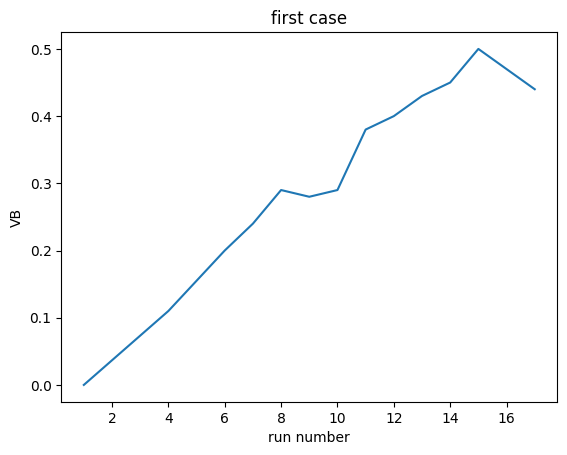

In [44]:
import matplotlib.pyplot as plt
VB_work = []
number = []
for i in range(167):
  run = mill[0,i]
  state = (not np.isnan(run["VB"].item()) and run["case"].item()== 1)

  if state:
    print("case=",run["case"],"VB=",run["VB"].item(),"run number=",i+1)
    VB_work.append(run["VB"].item())
    number.append(i+1)

plt.plot(number,VB_work)
plt.xlabel("run number")
plt.ylabel("VB")
plt.title("first case")
plt.show()


VB / Run


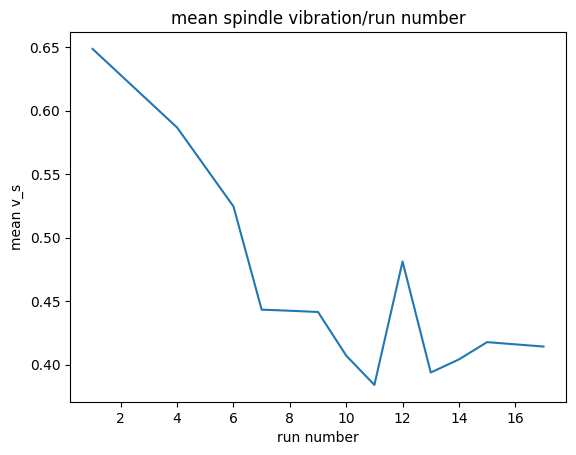

In [45]:
vib_spindle_cut_mean = []
for i in number:
  run = mill[0,i-1]
  vib_spindle_mean = np.mean(run["vib_spindle"][mask_cut])
  vib_spindle_cut_mean.append(vib_spindle_mean)

plt.plot(number,vib_spindle_cut_mean)
plt.title("mean spindle vibration/run number")
plt.ylabel("mean v_s")
plt.xlabel("run number")
plt.show()


the mean v_s/number figure without nan


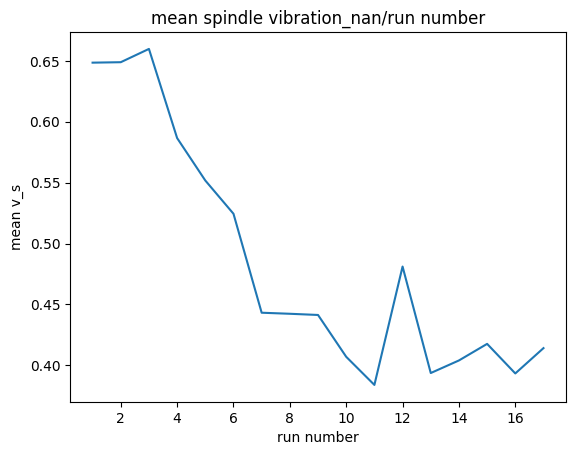

In [46]:
vib_spindle_cut_mean_nan = []
number_nan = []
for i in range(17):
  run = mill[0,i]
  vib_spindle_mean = np.mean(run["vib_spindle"][mask_cut])
  vib_spindle_cut_mean_nan.append(vib_spindle_mean)
  number_nan.append(i+1)

plt.plot(number_nan,vib_spindle_cut_mean_nan)
plt.title("mean spindle vibration_nan/run number")
plt.ylabel("mean v_s")
plt.xlabel("run number")
plt.show()


the vib with nan


run 12 vb= 0.4


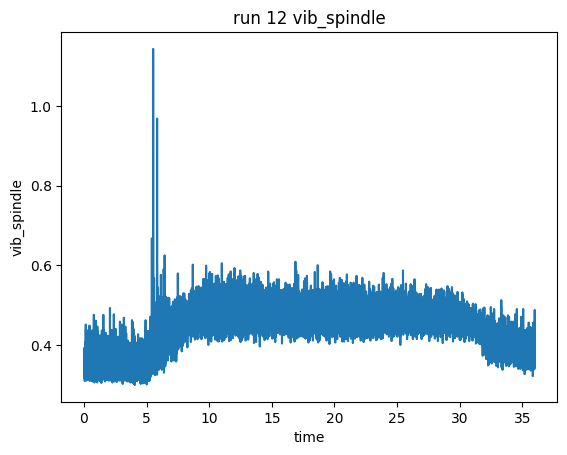

In [47]:
mill_12 = mill[0,11]["vib_spindle"]
print("run 12 vb=",mill[0,11]["VB"].item())

plt.plot(t_s,mill_12)
plt.title("run 12 vib_spindle")
plt.xlabel("time")
plt.ylabel("vib_spindle")
plt.show()


In [48]:
mean_mill_12_cut = np.mean(mill_12[mask_cut])
print(mean_mill_12_cut)


0.4811211375116698


run-12 vib_spindle abnormal high


run 11 vb= 0.38


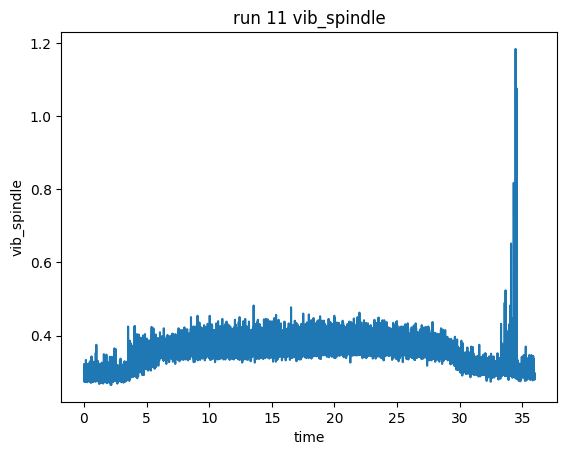

In [49]:
mill_11 = mill[0,10]["vib_spindle"]
print("run 11 vb=",mill[0,10]["VB"].item())

plt.plot(t_s,mill_11)
plt.title("run 11 vib_spindle")
plt.xlabel("time")
plt.ylabel("vib_spindle")
plt.show()


run 13 vb= 0.43


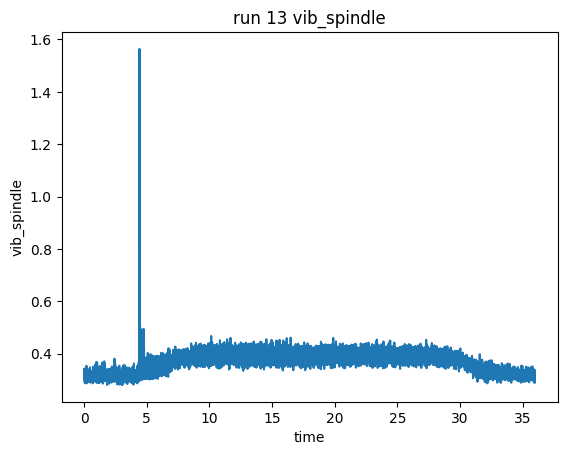

In [50]:
mill_13 = mill[0,12]["vib_spindle"]
print("run 13 vb=",mill[0,12]["VB"].item())

plt.plot(t_s,mill_13)
plt.title("run 13 vib_spindle")
plt.xlabel("time")
plt.ylabel("vib_spindle")
plt.show()


run 14 vb= 0.45


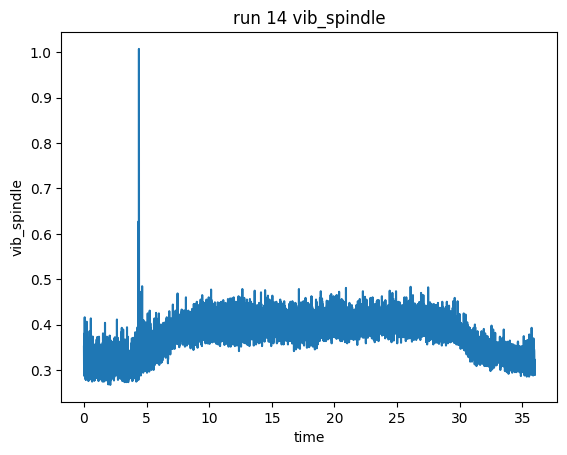

In [51]:
mill_14 = mill[0,13]["vib_spindle"]
print("run 14 vb=",mill[0,13]["VB"].item())

plt.plot(t_s,mill_14)
plt.title("run 14 vib_spindle")
plt.xlabel("time")
plt.ylabel("vib_spindle")
plt.show()


run 10 vb= 0.29


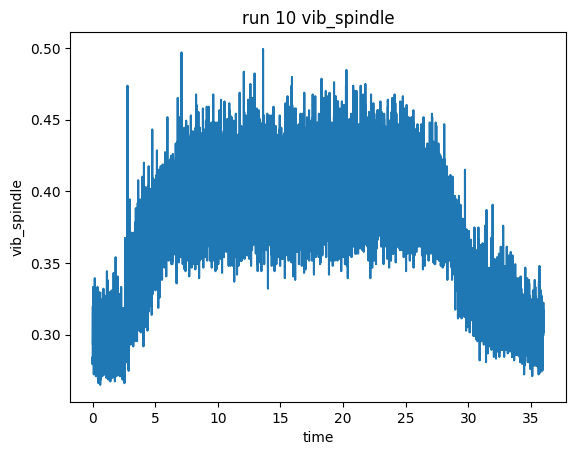

In [52]:
mill_10 = mill[0,9]["vib_spindle"]
print("run 10 vb=",mill[0,9]["VB"].item())

plt.plot(t_s,mill_10)
plt.title("run 10 vib_spindle")
plt.xlabel("time")
plt.ylabel("vib_spindle")
plt.show()


run 9 vb= 0.28


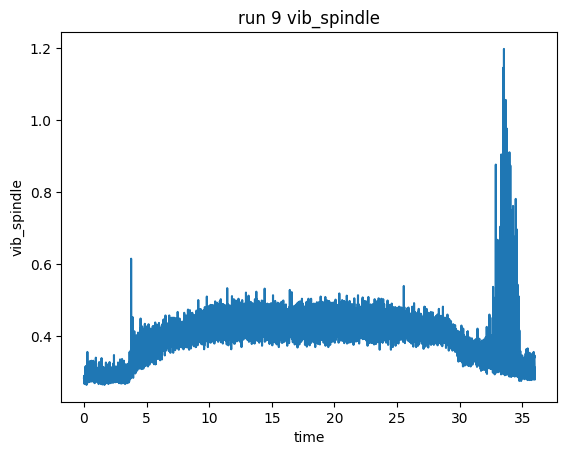

In [53]:
mill_9 = mill[0,8]["vib_spindle"]
print("run 9 vb=",mill[0,8]["VB"].item())

plt.plot(t_s,mill_9)
plt.title("run 9 vib_spindle")
plt.xlabel("time")
plt.ylabel("vib_spindle")
plt.show()


Text(0.5, 0, 'time')

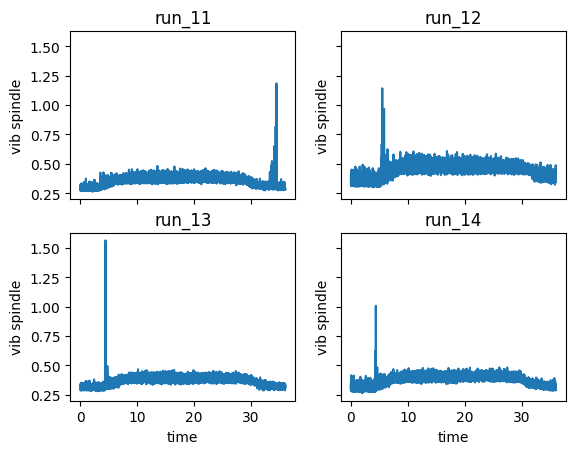

In [54]:
fig,axes = plt.subplots(2,2,sharex = True,sharey= True)
axes[0,0].plot(t_s,mill_11)
axes[0,0].set_ylabel("vib spindle")
axes[0,0].set_title("run_11")

axes[1,0].plot(t_s,mill_13)
axes[1,0].set_ylabel("vib spindle")
axes[1,0].set_title("run_13")
axes[1,0].set_xlabel("time")

axes[0,1].plot(t_s,mill_12)
axes[0,1].set_ylabel("vib spindle")
axes[0,1].set_title("run_12")

axes[1,1].plot(t_s,mill_14)
axes[1,1].set_ylabel("vib spindle")
axes[1,1].set_title("run_14")
axes[1,1].set_xlabel("time")


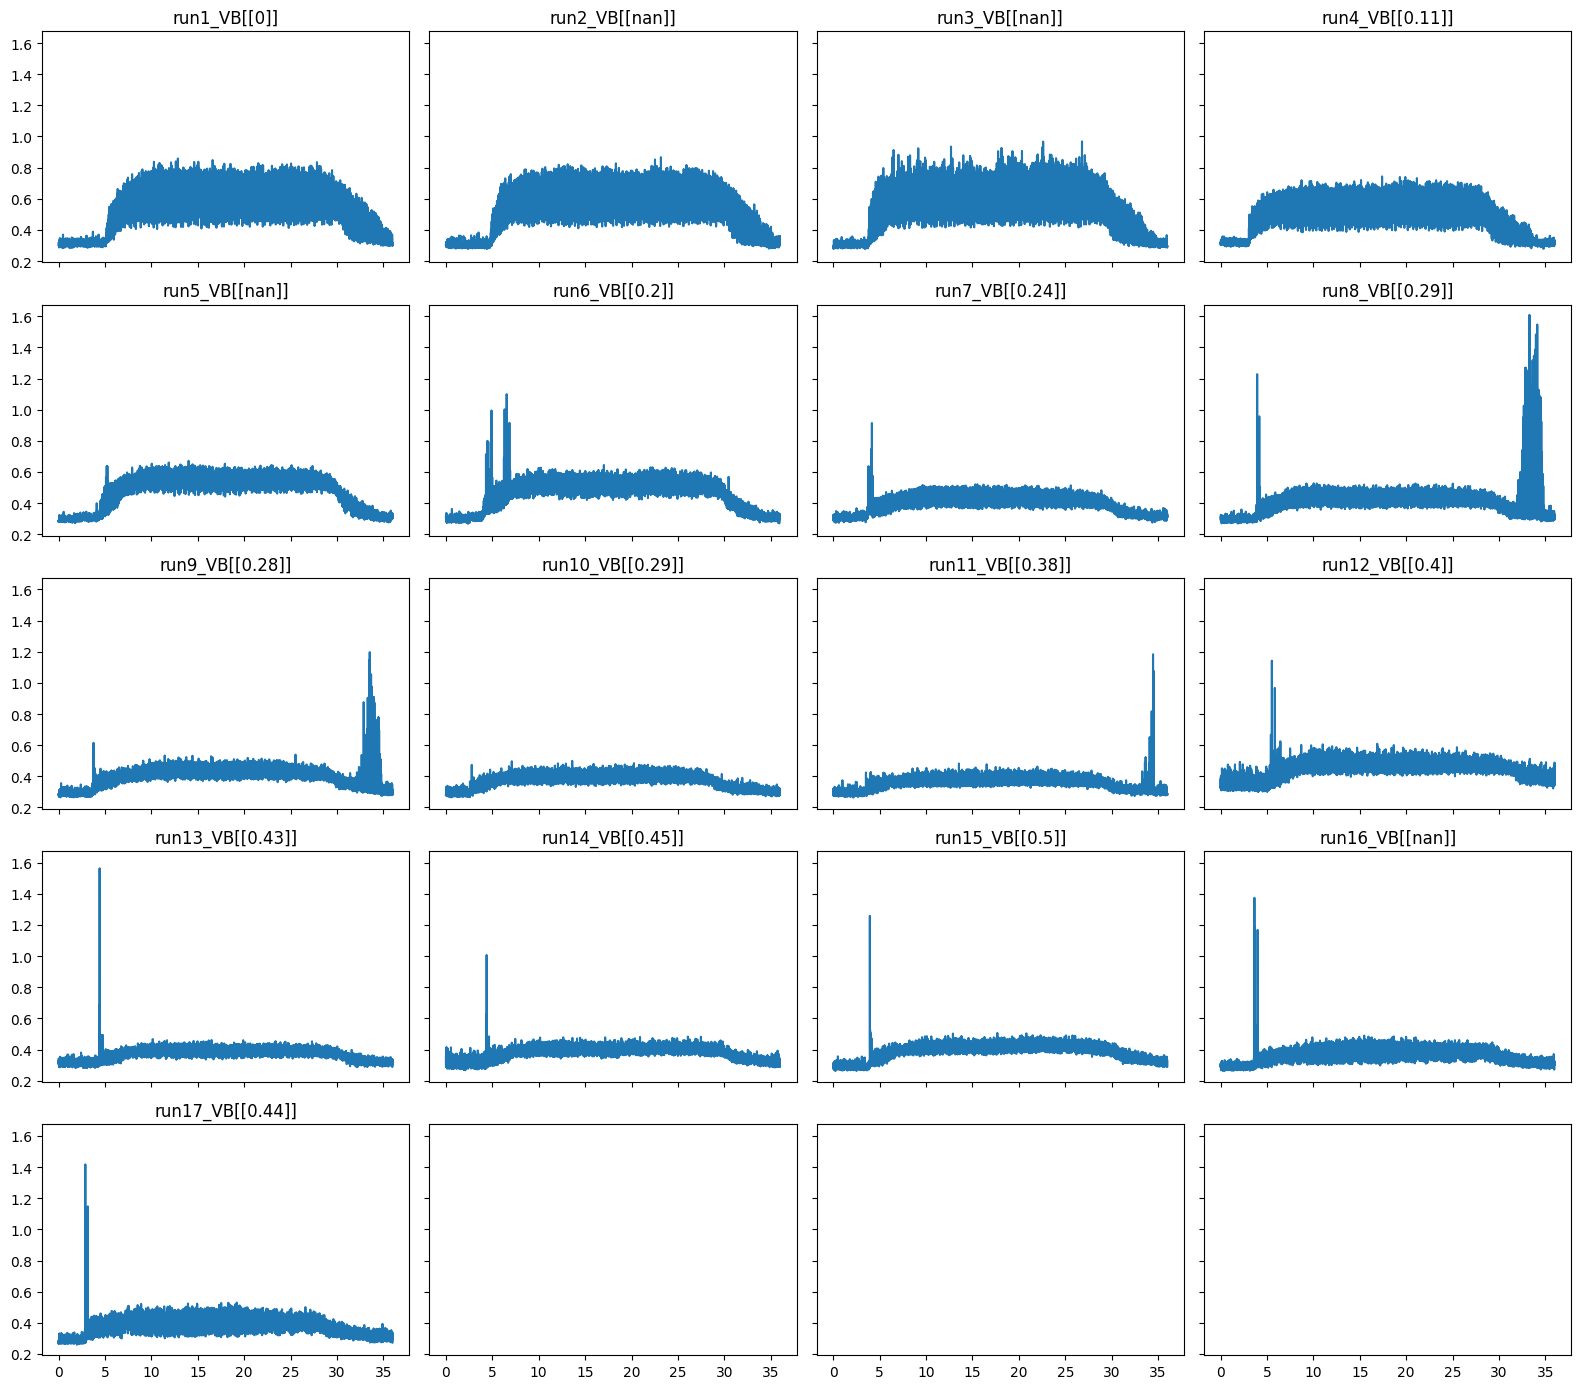

In [55]:
case_1_vib_s = []
for i in range(mill.shape[1]):
    run = mill[0, i]
    if run["case"].item() == 1:
     case_1_vib_s.append(i)
fig, axes = plt.subplots(5, 4, figsize=(16, 14),sharex=True, sharey=True)
for i in case_1_vib_s:
  run = mill[0, i]
  axes.flat[i].plot(t_s,run["vib_spindle"])
  axes.flat[i].set_title(f"run{i+1}_VB{run["VB"]}")
plt.tight_layout()
plt.show()
# print(case_1)
# print(len(case_1))


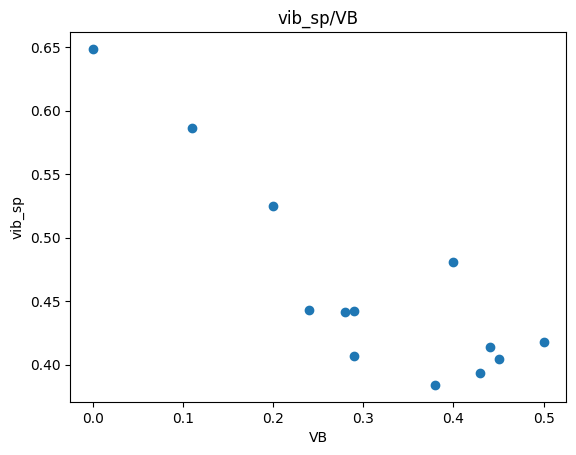

In [56]:
plt.scatter(VB_work,vib_spindle_cut_mean)
plt.title("vib_sp/VB")
plt.ylabel("vib_sp")
plt.xlabel("VB")
plt.show()


In [57]:
corr_matrix_mean = np.corrcoef(VB_work,vib_spindle_cut_mean)
#print(corr_matrix_mean)
r_mean = corr_matrix_mean[0,1]
print(r_mean)


-0.8626466487509021


use pearson correlation coefficient to discover linear relationship


In [58]:
std_run1 = np.std(mill[0,0]["vib_spindle"][mask_cut])
vib_spindle_cut_std = []
for i in number:
  run = mill[0,i-1]
  vib_spindle_std = np.std(run["vib_spindle"][mask_cut])
  vib_spindle_cut_std.append(vib_spindle_std)
print(np.array(vib_spindle_cut_std))


[0.07875024 0.06022453 0.03651107 0.03080332 0.03236167 0.02785777
 0.02558255 0.02387311 0.03550049 0.02102156 0.02223318 0.02386047
 0.03557258]


std for the run with VB recorded


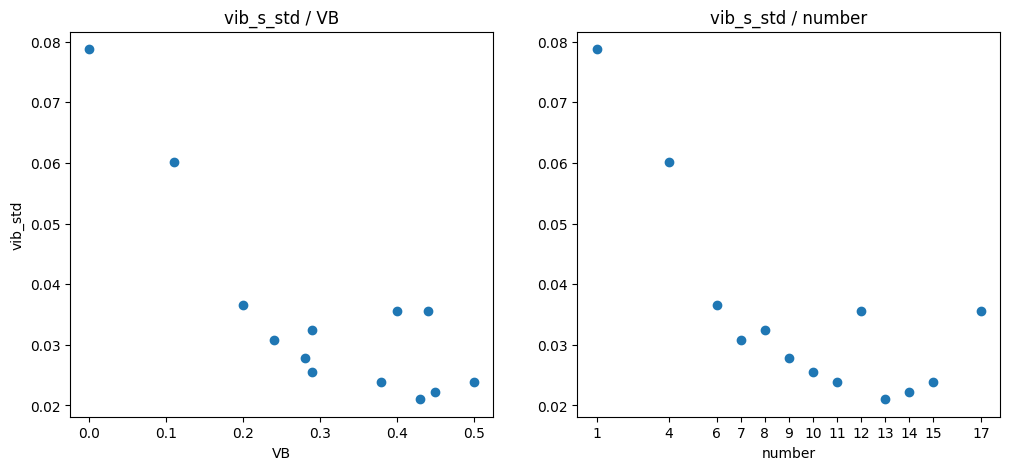

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(VB_work,vib_spindle_cut_std)
axes[0].set_title("vib_s_std / VB")
axes[0].set_ylabel("vib_std")
axes[0].set_xlabel("VB")

axes[1].scatter(number,vib_spindle_cut_std)
axes[1].set_title("vib_s_std / number")
axes[1].set_xlabel("number")
axes[1].set_xticks(number)


In [60]:
corrematrix_std = np.corrcoef(VB_work,vib_spindle_cut_std)
r_std = corrematrix_std[0,1]
print(r_std)


-0.8339148563427522


In [61]:
import pandas as pd

features_vib_sp = pd.DataFrame({
    "record_number": number,
    "VB": VB_work,
    "vib_mean": vib_spindle_cut_mean,
    "vib_std": vib_spindle_cut_std
})

display(features_vib_sp)


,record_number,VB,vib_mean,vib_std
0,1,0.00,0.648509,0.078750
1,4,0.11,0.586600,0.060225
2,6,0.20,0.524458,0.036511
3,7,0.24,0.443222,0.030803
4,8,0.29,0.442355,0.032362
5,9,0.28,0.441375,0.027858
6,10,0.29,0.407035,0.025583
7,11,0.38,0.383948,0.023873
8,12,0.40,0.481121,0.035500
9,13,0.43,0.393711,0.021022


In [62]:
a_vibs = np.polyfit(vib_spindle_cut_mean,VB_work,1)[0]
b_vibs = np.polyfit(vib_spindle_cut_mean,VB_work,1)[1]
print(a_vibs,b_vibs)



-1.5680241088875102 1.0307383568702266


In [63]:
# vib_mean_input = float(input("mean spindle vibration = "))
# VB_est = a*vib_mean_input + b
# print(VB_est)

In [64]:
VB_est_vibs_mean = a_vibs * features_vib_sp["vib_mean"] + b_vibs
print(VB_est_vibs_mean)
print(features_vib_sp["VB"])
VB_residual_abs_vibs_mean = abs(features_vib_sp["VB"] - VB_est_vibs_mean)
print(VB_residual_abs_vibs_mean)
VB_residual_vibs_mean = features_vib_sp["VB"] - VB_est_vibs_mean
print(VB_residual_vibs_mean)

0     0.013861
1     0.110936
2     0.208376
3     0.335755
4     0.337116
5     0.338652
6     0.392497
7     0.428699
8     0.276329
9     0.413390
10    0.397200
11    0.375862
12    0.381327
Name: vib_mean, dtype: float64
0     0.00
1     0.11
2     0.20
3     0.24
4     0.29
5     0.28
6     0.29
7     0.38
8     0.40
9     0.43
10    0.45
11    0.50
12    0.44
Name: VB, dtype: float64
0     0.013861
1     0.000936
2     0.008376
3     0.095755
4     0.047116
5     0.058652
6     0.102497
7     0.048699
8     0.123671
9     0.016610
10    0.052800
11    0.124138
12    0.058673
dtype: float64
0    -0.013861
1    -0.000936
2    -0.008376
3    -0.095755
4    -0.047116
5    -0.058652
6    -0.102497
7    -0.048699
8     0.123671
9     0.016610
10    0.052800
11    0.124138
12    0.058673
dtype: float64


VB and its residual

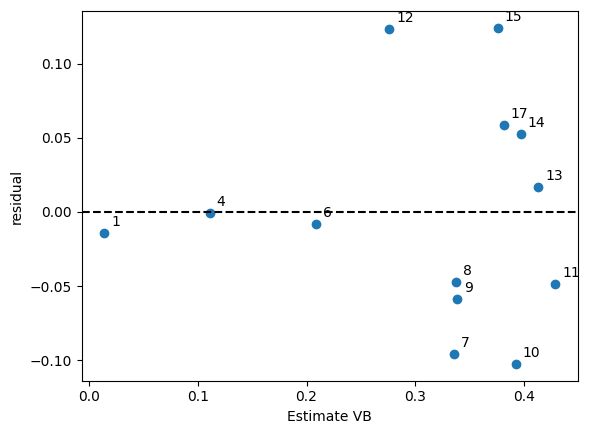

In [70]:
plt.scatter(VB_est_vibs_mean, VB_residual_vibs_mean)
plt.axhline(0, color="black", linestyle="--")
plt.ylabel("residual")
plt.xlabel("Estimate VB")

for n, x, y in zip(number, VB_est_vibs_mean, VB_residual_vibs_mean):
    plt.annotate(
        str(n),
        xy=(x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )
plt.show()

Estimated VB by vib_spin mean - residual


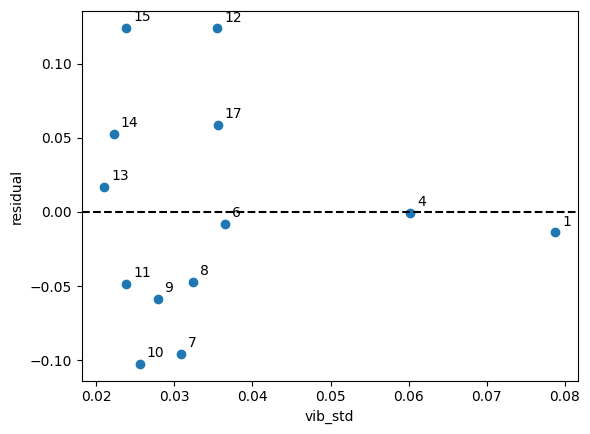

In [66]:
plt.scatter(features_vib_sp["vib_std"], VB_residual_vibs_mean)
plt.axhline(0, color="black", linestyle="--")
plt.ylabel("residual")
plt.xlabel("vib_std")

for n, x, y in zip(number, features_vib_sp["vib_std"], VB_residual_vibs_mean):
    plt.annotate(
        str(n),
        xy=(x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )
plt.show()

In [67]:
a_AEs = np.polyfit(vib_spindle_cut_std,VB_work,1)[0]
b_AEs = np.polyfit(vib_spindle_cut_std,VB_work,1)[1]
print(a_vibs,b_vibs)



-1.5680241088875102 1.0307383568702266


In [73]:
VB_est_vibs_std = a_AEs * features_vib_sp["vib_std"] + b_AEs
print(VB_est_vibs_std)
residual_vibs_std = features_vib_sp["VB"] - VB_est_vibs_std
print(residual_vibs_std)

0    -0.011435
1     0.123821
2     0.296953
3     0.338626
4     0.327248
5     0.360131
6     0.376742
7     0.389223
8     0.304332
9     0.410042
10    0.401196
11    0.389315
12    0.303805
Name: vib_std, dtype: float64
0     0.011435
1    -0.013821
2    -0.096953
3    -0.098626
4    -0.037248
5    -0.080131
6    -0.086742
7    -0.009223
8     0.095668
9     0.019958
10    0.048804
11    0.110685
12    0.136195
dtype: float64


estimated VB by vib_spin mean - residual

AE_spindle analysis

In [ ]:
AE_spindle_cut_mean = []
for i in number:
  run = mill[0,i-1]
  AE_spindle_mean = np.mean(run["AE_spindle"][mask_cut])
  AE_spindle_cut_mean.append(AE_spindle_mean)

plt.plot(number,AE_spindle_cut_mean)
plt.title("mean spindle AE/run number")
plt.ylabel("mean AE_s")
plt.xlabel("run number")
plt.show()


In [ ]:
case_1_AE_sp = []
for i in range(mill.shape[1]):
    run = mill[0, i]
    if run["case"].item() == 1:
     case_1_AE_sp.append(i)
fig, axes = plt.subplots(5, 4, figsize=(16, 14),sharex=True, sharey=True)
for i in case_1_AE_sp:
  run = mill[0, i]
  axes.flat[i].plot(t_s,run["AE_spindle"])
  axes.flat[i].set_title(f"run{i+1}_VB{run["VB"]}")
plt.tight_layout()
plt.show()

In [ ]:
plt.scatter(VB_work,AE_spindle_cut_mean)
plt.title("AE_sp/VB")
plt.ylabel("AE_sp")
plt.xlabel("VB")
plt.show()

AE_spin_mean / VB

In [74]:
pearcorr_meanAE_spin = np.corrcoef(VB_work,AE_spindle_cut_mean)
print(pearcorr_meanAE_spin[0,1])

0.9113275145499792


In [ ]:
AE_spindle_cut_std = []
for i in number:
  run = mill[0,i-1]
  AE_spindle_std = np.std(run["AE_spindle"][mask_cut])
  AE_spindle_cut_std.append(AE_spindle_std)

plt.plot(number,AE_spindle_cut_std)
plt.title("std spindle AE/run number")
plt.ylabel("std AE_s")
plt.xlabel("run number")
plt.show()


In [ ]:
plt.scatter(VB_work,AE_spindle_cut_std)
plt.title("std_AE_sp/VB")
plt.ylabel("std_AE_sp")
plt.xlabel("VB")
plt.show()

In [ ]:
pearcorr_meanAE_spin = np.corrcoef(VB_work,AE_spindle_cut_std)
print(pearcorr_meanAE_spin[0,1])

In [ ]:
features_AE_sp = pd.DataFrame({
    "record_number": number,
    "VB": VB_work,
    "AE_mean": AE_spindle_cut_mean,
    "AE_std": AE_spindle_cut_std
})

display(features_AE_sp)
